In [1]:
import json
import os
import random

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import inception_v3
from tqdm.auto import tqdm
from sklearn.metrics import f1_score  # criterio de best-checkpoint (F1-macro en validación)
import wandb  # pip install wandb, si no esta ya en el entorno del workstation


/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cuda


In [3]:
SEED = 42


def seed_everything(seed=SEED):
    """Fija todas las fuentes de aleatoriedad del notebook.

    Cubre la init de la cabeza (linear1/bn1/linear2 en FullModel), el
    shuffle del DataLoader de train y la RandomRotation/RandomHorizontalFlip
    del train_transform (usan el RNG global de torch porque el DataLoader
    corre con num_workers=0). Mismo patrón que scripts/gen_lr_backbone_grid.py
    (exp10-exp19) — mantenerlo consistente si se copia esta celda a nuevos
    notebooks del bloque exp24+.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Determinismo en cuDNN: reproducible a costa de algo de velocidad.
    # Con benchmark=True cuDNN elige algoritmos según el hardware y la
    # misma semilla deja de dar el mismo resultado entre máquinas.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything()
print(f"Semilla fijada: {SEED} (cudnn.deterministic=True, benchmark=False)")

Semilla fijada: 42 (cudnn.deterministic=True, benchmark=False)


In [4]:
EXP_ID = "exp47"
RUN_NAME = "exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010"
UNFROZEN_DESC = "solo la última etapa (Mixed_7a/7b/7c) descongelada"
ARCHITECTURE = "inception_v3"  # InceptionV3, la otra arquitectura publicada por RadImageNet junto a resnet50 (ver weight_loaders/_keymaps.py::SUPPORTED_ARCHS del paquete)
DEPTH_LABEL = "Mixed_7a-c"  # solo para títulos de gráficas, ver celda de loss curve
# bloque 10: bloque 9 (sampler balanceado, split 70/20/10) extendido a
# arquitecturas nuevas publicadas por RadImageNet (InceptionV3, DenseNet121),
# a 2 profundidades (backbone congelado vs. solo la última etapa descongelada)
# en vez de las 5 profundidades del bloque 9 -- ResNet50 sigue cubierto por
# exp42-exp46.
BLOCK = 10
# Índices de backbone a descongelar — ver freeze cell para el mapa completo
# (distinto de exp42-46: la indexación depende de la arquitectura).
UNFREEZE_IDX = [15, 16, 17]
HEAD = "mlp"

# alpha del muestreador: w_i = n_celda ** (-SAMPLER_ALPHA). Con 1.0 las 8
# celdas (4 bases x 2 clases) quedan equiprobables y P(maligno|dataset)=0.5 en
# todas; con 0.0 se recupera el muestreo natural de los bloques 6/7.
SAMPLER_ALPHA = 1.0

LR = 1e-04            # cabeza (linear1/bn1/linear2/bn2/linear3)
LR_BACKBONE = 1e-04   # backbone descongelado — igual a LR, para comparar 1-a-1 contra exp42-46
DROPOUT = 0.5
WEIGHT_DECAY = 1e-04
BATCH_SIZE = 16
NUM_EPOCHS = 100
PATIENCE = 20
IMAGE_SIZE = 299  # InceptionV3 requiere >=299px (pooling strides fijos); a 256px (la convención del resto del bloque) produce activaciones incorrectas
ROTATION_DEGREES = 7

PROJECT_ROOT = Path(
    "/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/"
    "Federal Learning/infraestructura federada/Federal-Learning"
)

DATASET_ROOT = Path(
    "/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/02-Databases/Mammo-Bench/"
    "c86fb00c-0fb8-4e0e-85a2-4d415f9c1ada_1a9410d8-9769-4064-a064-0160f2fd193d_"
    "DATASET-FILE_Mammo_Bench_zip_20241225112148174/Mammo_Data/Mammo-Bench"
)

# Split 70/20/10 (bloques 6-8 usaban 80/10/10 vía manifests/fedmammobench.csv).
# Mismo manifest que exp42-46 — ver esos notebooks para el detalle de cómo se
# generó (scripts/resplit_manifest_70_20_10.py, test bit a bit idéntico).
SPLIT_SCHEME = "70/20/10"
MANIFEST_PATH = PROJECT_ROOT / "manifests" / "fedmammobench_70_20_10.csv"
# Checkpoint RadImageNet tal cual lo publica el proyecto oficial (BMEII-AI/RadImageNet):
# backbone guardado como nn.Sequential, sin prefijo "RadImageNet-{arch}" (ese es solo
# el nombre que espera el loader del paquete vía $FEDMAMMOBENCH_RADIMAGENET_DIR, que
# estos notebooks standalone no usan). Ver load_radimagenet_backbone más abajo para el
# remapeo de claves, verificado contra el contenido real del .pt.
RADIMAGENET_WEIGHTS_PATH = PROJECT_ROOT / "weights" / "InceptionV3.pt"

# W&B: la API key NUNCA se pega aquí. Se lee de la variable de entorno
# WANDB_API_KEY, o de las credenciales cacheadas en ~/.netrc tras correr
# `wandb login` una vez en este workstation (a diferencia de los
# contenedores Docker del paquete, aqui el notebook SI hereda ese
# ~/.netrc porque corre directo en el host, sin aislar el filesystem).
WANDB_PROJECT = "fedmammobench"
WANDB_ENTITY = None  # None -> entity por defecto de la API key
WANDB_MODE = "online"  # "online" | "offline" | "disabled"
WANDB_TAGS = ['notebook', 'centralized', 'radimagenet', 'mammobench', 'inceptionv3', 'mixed7', 'img299', 'balanced-sampler', 'split702010']

RUN_DIR = PROJECT_ROOT / "runs" / RUN_NAME
PLOTS_DIR = RUN_DIR / "plots"
# Métricas/gráficas globales (todo el test set) van en PLOTS_DIR y metrics.json.
# El desglose por source_dataset va aparte, en su propia carpeta, para no
# mezclar los dos niveles de granularidad.
PER_DATASET_DIR = RUN_DIR / "per_dataset"
RUN_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
PER_DATASET_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = RUN_DIR / "best_model.pth"
LAST_MODEL_PATH = RUN_DIR / "last_model.pth"

print(f"RUN_DIR: {RUN_DIR}")


RUN_DIR: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010


In [5]:
# W&B init. `WandbWriter` (src/fedmammobench/utils/wandb_utils.py) hace este
# mismo degradado en el paquete; aqui se replica a mano porque el notebook no
# importa fedmammobench. Nunca debe bloquear ni pedir la key por input():
# si no hay credenciales, cae a modo offline (o se desactiva del todo).
os.environ.setdefault("WANDB_SILENT", "true")

wandb_run = None
if WANDB_MODE != "disabled":
    mode = WANDB_MODE
    has_creds = bool(os.environ.get("WANDB_API_KEY", "").strip()) or bool(wandb.api.api_key)
    if mode == "online" and not has_creds:
        print(
            "No hay WANDB_API_KEY ni credenciales cacheadas (~/.netrc); "
            "corriendo wandb en modo offline. Sincroniza despues con "
            "`wandb sync` sobre la carpeta wandb/ de este run."
        )
        mode = "offline"

    try:
        wandb_run = wandb.init(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=RUN_NAME,
            group=EXP_ID,
            tags=WANDB_TAGS,
            mode=mode,
            dir=str(RUN_DIR),
            config={
                "exp_id": EXP_ID,
                "seed": SEED,
                "block": BLOCK,
                "architecture": ARCHITECTURE,
                "manifest": MANIFEST_PATH.name,
                "split_scheme": SPLIT_SCHEME,
                "unfrozen": UNFROZEN_DESC,
                "unfreeze_idx": UNFREEZE_IDX,
                "head": HEAD,
                "loss": "CrossEntropyLoss",
                "class_weight": None,  # el balanceo lo hace el sampler, no la loss
                "sampler": "WeightedRandomSampler(source_dataset x clase)",
                "sampler_alpha": SAMPLER_ALPHA,
                "lr": LR,
                "lr_backbone": LR_BACKBONE if HEAD == "mlp" else None,
                "dropout": DROPOUT if HEAD == "mlp" else None,
                "weight_decay": WEIGHT_DECAY,
                "batch_size": BATCH_SIZE,
                "num_epochs": NUM_EPOCHS,
                "patience": PATIENCE,
                "image_size": IMAGE_SIZE,
                "rotation_degrees": ROTATION_DEGREES,
            },
        )
        print(f"W&B run ({mode}): {getattr(wandb_run, 'url', None) or RUN_DIR / 'wandb'}")
    except Exception as exc:
        print(f"wandb.init() fallo ({exc!r}); se continua sin W&B.")
        wandb_run = None
else:
    print("W&B desactivado (WANDB_MODE = 'disabled').")

W&B run (online): https://wandb.ai/j-mast8924-instituci-n-universitaria-itm/fedmammobench/runs/xa6nxree


In [6]:
SPLIT_COL = "split"
LABEL_COL = "classification"
PATH_COL = "preprocessed_image_path"

TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT = "train", "val", "test"


class CSVDataset(Dataset):
    def __init__(self, csv_file=None, split=None, root_dir="", transform=None, label_to_idx=None,
                 dataframe=None):
        if dataframe is not None:
            # Filas ya resueltas por el llamador (p.ej. un subset de test_processed.data
            # filtrado por source_dataset) — se usan tal cual, sin leer ni filtrar por split.
            self.data = dataframe.reset_index(drop=True)
        else:
            self.data = pd.read_csv(csv_file)

            missing = {SPLIT_COL, LABEL_COL, PATH_COL} - set(self.data.columns)
            if missing:
                raise KeyError(
                    f"El manifest {csv_file} no tiene la(s) columna(s) {sorted(missing)}. "
                    f"Columnas disponibles: {list(self.data.columns)}"
                )

            available = sorted(self.data[SPLIT_COL].dropna().unique())
            if split not in available:
                raise ValueError(
                    f"split={split!r} no existe en la columna {SPLIT_COL!r}. "
                    f"Valores disponibles: {available}"
                )

            self.data = self.data[self.data[SPLIT_COL] == split].reset_index(drop=True)

        if len(self.data) == 0:
            source = f"split {split!r}" if dataframe is None else "el dataframe recibido"
            raise ValueError(f"El dataset quedó vacío ({source}).")

        self.root_dir = Path(root_dir)
        self.transform = transform

        if label_to_idx is None:
            labels = sorted(self.data[LABEL_COL].unique())
            self.label_to_idx = {label: i for i, label in enumerate(labels)}
        else:
            self.label_to_idx = label_to_idx

        unknown = set(self.data[LABEL_COL].unique()) - set(self.label_to_idx)
        if unknown:
            raise ValueError(
                f"Hay etiquetas {sorted(unknown)} ausentes en label_to_idx={self.label_to_idx}."
            )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_path = Path(self.root_dir) / Path(row[PATH_COL])
        image = Image.open(img_path).convert("RGB")

        label = self.label_to_idx[row[LABEL_COL]]

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
_manifest = pd.read_csv(MANIFEST_PATH)

_required = {SPLIT_COL, LABEL_COL, PATH_COL}
assert _required <= set(_manifest.columns), (
    f"Faltan columnas en el manifest: {sorted(_required - set(_manifest.columns))}"
)

_splits = sorted(_manifest[SPLIT_COL].dropna().unique())
assert set(_splits) >= {TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT}, (
    f"El manifest solo tiene splits {_splits}; se esperaban "
    f"{[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT]}"
)

print(f"Filas totales: {len(_manifest)}\n")
print(pd.crosstab(_manifest[SPLIT_COL], _manifest[LABEL_COL], margins=True))

if "source_dataset" in _manifest.columns:
    print()
    print(pd.crosstab(_manifest["source_dataset"], _manifest[SPLIT_COL], margins=True))

Filas totales: 8341

classification  Benign  Malignant   All
split                                  
test               557        277   834
train             3847       1992  5839
val               1101        567  1668
All               5505       2836  8341

split           test  train   val   All
source_dataset                         
cdd-cesm         100    702   201  1003
cmmd             472   3306   944  4722
inbreast          40    288    82   410
kau-bcmd         222   1543   441  2206
All              834   5839  1668  8341


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(ROTATION_DEGREES),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [9]:
train_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=TRAIN_SPLIT, root_dir=DATASET_ROOT,
    transform=train_transform,
)
validation_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=VAL_SPLIT, root_dir=DATASET_ROOT,
    transform=val_transform, label_to_idx=train_processed.label_to_idx,
)
test_processed = CSVDataset(
    csv_file=MANIFEST_PATH, split=TEST_SPLIT, root_dir=DATASET_ROOT,
    transform=val_transform, label_to_idx=train_processed.label_to_idx,
)

print(f"label_to_idx: {train_processed.label_to_idx}")
print(f"train: {len(train_processed)} | val: {len(validation_processed)} | test: {len(test_processed)}")

label_to_idx: {'Benign': 0, 'Malignant': 1}
train: 5839 | val: 1668 | test: 834


In [10]:
# Muestreo balanceado por celda (source_dataset x clase) — la regularización
# central de este bloque. En train, P(maligno | dataset) va de 0.046 (kau-bcmd)
# a 0.489 (cmmd), asi que identificar la base de origen (trivial: escáner,
# preprocesado, histograma) reduce la loss sin mirar la lesión. Los resultados
# del bloque 7 lo confirman: sobre las imágenes BENIGNAS del test, la
# probabilidad media que emite el modelo correlaciona r=0.98 con la prevalencia
# de su base de origen — el modelo aprendió P(maligno | dataset), no la lesión.
#
# w_i = n_c ** (-SAMPLER_ALPHA), con c = celda (source_dataset, clase) de la
# imagen i. Con alpha=1 las 8 celdas quedan equiprobables => P(maligno|dataset)
# = 0.5 en las cuatro => la identidad de la base deja de informar la etiqueta y
# el atajo se queda sin gradiente: la unica via para bajar la loss es separar
# maligno de benigno DENTRO de cada dominio.
_loader_generator = torch.Generator()
_loader_generator.manual_seed(SEED)


def _seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


# transform("size") difunde el tamaño del grupo a cada fila SIN reordenar, y eso
# es imprescindible: CSVDataset.__getitem__ usa self.data.iloc[idx] (indexación
# posicional) y WeightedRandomSampler indexa por esa misma posición, o sea que
# w[i] tiene que corresponder a train_processed[i]. Un merge o un
# groupby().apply() pueden reordenar y desalinearían los pesos en silencio.
_cell_sizes = (
    train_processed.data
    .groupby(["source_dataset", LABEL_COL])[LABEL_COL]
    .transform("size")
    .to_numpy()
)
_sample_weights = _cell_sizes.astype(np.float64) ** (-SAMPLER_ALPHA)
_sample_weights = _sample_weights / _sample_weights.mean()  # media 1: solo legibilidad

train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(_sample_weights, dtype=torch.double),
    num_samples=len(train_processed),  # misma longitud de época que exp28-exp36: mismos pasos/época
    replacement=True,                  # obligatorio para sobremuestrear las celdas raras
    generator=_loader_generator,       # el sorteo consume RNG; sembrarlo como el shuffle que sustituye
)

# drop_last=True: la cabeza usa BatchNorm1d, que revienta si el último batch de
# la época queda con 1 sola muestra.
# Sin shuffle=True: es incompatible con sampler, y el sampler ya aporta la
# aleatoriedad.
# val/test SIN sampler: la evaluación tiene que ver la distribución natural o
# las métricas son ficción.
train = DataLoader(
    train_processed, batch_size=BATCH_SIZE, sampler=train_sampler, drop_last=True,
    worker_init_fn=_seed_worker,
)
validation = DataLoader(validation_processed, batch_size=BATCH_SIZE, shuffle=False)
test = DataLoader(test_processed, batch_size=BATCH_SIZE, shuffle=False)

# Verificación de alineación: si los pesos estuvieran desplazados respecto al
# orden posicional del Dataset, el sampler sobremuestrearía imágenes
# equivocadas y nada avisaría. Sorteamos una época con un generator aparte (no
# perturbar el de train) y miramos la composición que sale.
_check_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(_sample_weights, dtype=torch.double),
    num_samples=len(train_processed), replacement=True,
    generator=torch.Generator().manual_seed(SEED),
)
_idx = np.fromiter(iter(_check_sampler), dtype=np.int64)
_drawn = train_processed.data.iloc[_idx]
_malignant = sorted(train_processed.label_to_idx, key=train_processed.label_to_idx.get)[1]
print(f"SAMPLER_ALPHA={SAMPLER_ALPHA} | pesos {_sample_weights.min():.3f}..{_sample_weights.max():.3f} "
      f"(ratio {_sample_weights.max() / _sample_weights.min():.1f}x)")
print(f"únicas por época: {len(np.unique(_idx))}/{len(train_processed)} "
      f"({len(np.unique(_idx)) / len(train_processed) * 100:.0f}%)")
print(f"P({_malignant} | dataset) en el sorteo (objetivo 0.500 con alpha=1):")
for _ds, _row in pd.crosstab(_drawn["source_dataset"], _drawn[LABEL_COL], normalize="index").iterrows():
    print(f"  {_ds:10} {_row.get(_malignant, 0.0):.3f}")
del _check_sampler, _idx, _drawn

SAMPLER_ALPHA=1.0 | pesos 0.432..10.427 (ratio 24.1x)
únicas por época: 2699/5839 (46%)
P(Malignant | dataset) en el sorteo (objetivo 0.500 con alpha=1):
  cdd-cesm   0.509
  cmmd       0.511
  inbreast   0.499
  kau-bcmd   0.492


In [11]:
class Classifier(nn.Module):
    def __init__(self, num_class):
        super().__init__()
        self.linear = nn.Linear(2048, num_class)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)


class Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        base_model = inception_v3(weights=None, aux_logits=False)
        encoder_layers = list(base_model.children())
        # 0-17 = Conv2d_1a_3x3..Mixed_7c, 18 = avgpool; excluye dropout(19)/fc(20).
        self.backbone = nn.Sequential(*encoder_layers[:19])

    def forward(self, x):
        return self.backbone(x)


In [12]:
def load_radimagenet_backbone(weights_path, device="cpu"):
    model = inception_v3(weights=None, aux_logits=False)
    checkpoint = torch.load(weights_path, map_location=device)

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

    # InceptionV3.pt (RadImageNet oficial) guarda el backbone como
    # nn.Sequential, así que sus claves son "backbone.N.weight" en vez de
    # "Mixed_7c.branch1x1.conv.weight". El índice N coincide 1 a 1 con
    # list(inception_v3(...).children())[N]: maxpool1/maxpool2 (sin parámetros,
    # índices 3 y 6) faltan en el checkpoint exactamente igual que en esa
    # lista -- verificado inspeccionando las claves reales del .pt antes de
    # escribir esta tabla, no asumido por analogía con resnet50.
    backbone_remap = {
        "backbone.0.": "Conv2d_1a_3x3.",
        "backbone.1.": "Conv2d_2a_3x3.",
        "backbone.2.": "Conv2d_2b_3x3.",
        "backbone.4.": "Conv2d_3b_1x1.",
        "backbone.5.": "Conv2d_4a_3x3.",
        "backbone.7.": "Mixed_5b.",
        "backbone.8.": "Mixed_5c.",
        "backbone.9.": "Mixed_5d.",
        "backbone.10.": "Mixed_6a.",
        "backbone.11.": "Mixed_6b.",
        "backbone.12.": "Mixed_6c.",
        "backbone.13.": "Mixed_6d.",
        "backbone.14.": "Mixed_6e.",
        "backbone.15.": "Mixed_7a.",
        "backbone.16.": "Mixed_7b.",
        "backbone.17.": "Mixed_7c.",
    }
    remapped_state_dict = {}
    for k, v in state_dict.items():
        new_k = k
        for old_prefix, new_prefix in backbone_remap.items():
            if k.startswith(old_prefix):
                new_k = new_prefix + k[len(old_prefix):]
                break
        remapped_state_dict[new_k] = v
    state_dict = remapped_state_dict

    state_dict = {
        k: v for k, v in state_dict.items()
        if k.startswith((
            "Conv2d_1a_3x3", "Conv2d_2a_3x3", "Conv2d_2b_3x3",
            "Conv2d_3b_1x1", "Conv2d_4a_3x3",
            "Mixed_5b", "Mixed_5c", "Mixed_5d",
            "Mixed_6a", "Mixed_6b", "Mixed_6c", "Mixed_6d", "Mixed_6e",
            "Mixed_7a", "Mixed_7b", "Mixed_7c",
        ))
    }

    if len(state_dict) == 0:
        raise RuntimeError(
            "0 RadImageNet tensors matched the model after remapping — "
            "check the checkpoint's key format before continuing."
        )

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f"Loaded {len(state_dict)} RadImageNet tensors into the backbone.")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    # Trunca a Conv2d_1a_3x3..avgpool (índices 0-18) para que la salida
    # (batch, 2048, 1, 1) encaje con el Linear(2048, ...) de la cabeza; excluye
    # dropout (19) y fc (20), que se reemplazan por la cabeza MLP propia.
    encoder_layers = list(model.children())
    return nn.Sequential(*encoder_layers[:19])


backbone = load_radimagenet_backbone(RADIMAGENET_WEIGHTS_PATH, device=device).to(device)


/media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/.venv/lib/python3.12/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Loaded 564 RadImageNet tensors into the backbone.
Missing keys: ['fc.weight', 'fc.bias']
Unexpected keys: []


In [13]:
# Índices de backbone (nn.Sequential, ver backbone_remap en load_radimagenet_backbone):
# 0=Conv2d_1a_3x3, 1=Conv2d_2a_3x3, 2=Conv2d_2b_3x3, 3=maxpool1(sin params),
# 4=Conv2d_3b_1x1, 5=Conv2d_4a_3x3, 6=maxpool2(sin params), 7-9=Mixed_5b/c/d,
# 10=Mixed_6a, 11-14=Mixed_6b/c/d/e, 15=Mixed_7a, 16-17=Mixed_7b/c (última
# etapa, análoga a layer4 de ResNet50), 18=avgpool(sin params). UNFREEZE_IDX
# se fija en la celda de parámetros.
for param in backbone.parameters():
    param.requires_grad = False
for idx in UNFREEZE_IDX:
    for param in backbone[idx].parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
total = sum(p.numel() for p in backbone.parameters())
pct = 100 * trainable / total
print(f"[{EXP_ID}] Backbone trainable params: {trainable:,} / {total:,} ({pct:.2f}%)")


[exp47] Backbone trainable params: 12,819,712 / 21,785,568 (58.84%)


In [14]:
train_loss_history = []
val_loss_history = []
val_f1_history = []


def freeze_bn_running_stats(module):
    # requires_grad=False congela gamma/beta pero NO running_mean/running_var,
    # que se siguen actualizando en cada forward en modo train(). eval() las fija.
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d) and not m.weight.requires_grad:
            m.eval()


def train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS, sheduler=None,
                patience=PATIENCE):
    # Best-checkpoint y early stopping se rigen por F1-macro en validación, no
    # por la loss: con clases desbalanceadas la loss puede seguir bajando
    # (el modelo se vuelve más "seguro") mientras el F1 de la clase minoritaria
    # empeora, así que es un mejor criterio de "mejor modelo" que la loss sola.
    best_val_f1 = -1.0
    train_loss_history.clear()
    val_loss_history.clear()
    val_f1_history.clear()
    counter = 0
    best_epoch = 0

    epoch_bar = tqdm(range(num_epochs), desc="Epochs", unit="epoch")
    for e in epoch_bar:
        train_loss = 0.0
        model.train()
        freeze_bn_running_stats(model)
        train_bar = tqdm(train, desc=f"  train {e+1}/{num_epochs}", unit="batch", leave=False)
        for data, labels in train_bar:
            # CrossEntropyLoss espera índices de clase (long), no floats.
            data, labels = data.to(device, dtype=torch.float), labels.to(device, dtype=torch.long)

            optimizer.zero_grad()
            target = model(data)
            loss = criterion(target, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        valid_loss = 0.0
        val_preds_epoch, val_labels_epoch = [], []
        model.eval()
        val_bar = tqdm(validation, desc=f"  val   {e+1}/{num_epochs}", unit="batch", leave=False)
        with torch.no_grad():
            for data, labels in val_bar:
                data, labels = data.to(device, dtype=torch.float), labels.to(device, dtype=torch.long)

                target = model(data)
                loss = criterion(target, labels)
                valid_loss += loss.item()
                val_bar.set_postfix(loss=f"{loss.item():.4f}")

                val_preds_epoch.extend(torch.argmax(target, dim=1).cpu().numpy())
                val_labels_epoch.extend(labels.cpu().numpy())

        avg_train_loss = train_loss / len(train)
        avg_valid_loss = valid_loss / len(validation)
        avg_valid_f1 = f1_score(val_labels_epoch, val_preds_epoch, average="macro")
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_valid_loss)
        val_f1_history.append(avg_valid_f1)
        epoch_bar.set_postfix(
            train_loss=f"{avg_train_loss:.4f}", val_loss=f"{avg_valid_loss:.4f}", val_f1=f"{avg_valid_f1:.4f}",
        )

        if wandb_run is not None:
            wandb_run.log(
                {
                    "train/loss": avg_train_loss,
                    "val/loss": avg_valid_loss,
                    "val/f1_macro": avg_valid_f1,
                },
                step=e + 1,
            )

        print(
            f"Epoch {e+1} \t\t Training Loss: {avg_train_loss} \t\t "
            f"Validation Loss: {avg_valid_loss} \t\t Validation F1-macro: {avg_valid_f1:.6f}"
        )

        torch.save(model.state_dict(), LAST_MODEL_PATH)

        if avg_valid_f1 > best_val_f1:
            print(f"Validation F1-macro increased({best_val_f1:.6f}--->{avg_valid_f1:.6f}) \t Saving The Model")
            best_val_f1 = avg_valid_f1
            best_epoch = e + 1
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            counter = 0
        else:
            counter += 1
            print(f"EarlyStopping counter: {counter} out of {patience}")

        if counter >= patience:
            print(f"Early stopping triggered en la época {e+1}. Mejor época: {best_epoch}.")
            break

        if sheduler is not None:
            sheduler.step()

    print(f"\nMejor época: {best_epoch} (val F1-macro {best_val_f1:.6f}) -> {BEST_MODEL_PATH}")
    print(f"Última época: {len(train_loss_history)} -> {LAST_MODEL_PATH}")
    return model

In [15]:
class FullModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.linear1  = nn.Linear(2048, 512)
        self.bn1      = nn.BatchNorm1d(512)
        self.act1     = nn.ReLU(inplace=True)
        self.dropout1 = nn.Dropout(p=DROPOUT)

        self.linear2  = nn.Linear(512, 512)
        self.bn2      = nn.BatchNorm1d(512)
        self.act2     = nn.ReLU(inplace=True)
        self.dropout2 = nn.Dropout(p=DROPOUT)

        # 2 logits (benigno/maligno) para CrossEntropyLoss, en vez de 1 logit
        # + sigmoid (BCEWithLogitsLoss).
        self.linear3  = nn.Linear(512, 2)

    def forward(self, x):

        x = self.backbone(x)
        x = x.view(x.size(0), -1)

        x = self.linear1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)

        x = self.linear2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)

        x = self.linear3(x)
        return x  # logits [batch, 2] crudos; CrossEntropyLoss aplica softmax internamente


# Re-sembrar aquí hace que los pesos iniciales de la cabeza (linear1/bn1/
# linear2/bn2/linear3) no dependan de cuántas celdas se hayan ejecutado antes
# (Jupyter permite ejecutarlas en cualquier orden, y el RNG global es estado
# compartido).
seed_everything()  # pesos iniciales de la cabeza reproducibles
model = FullModel(backbone).to(device)

# linear1/linear2/linear3 se reinicializan con una distribución normal en vez
# del kaiming_uniform por defecto de nn.Linear — incluyendo linear3, que es la
# capa de salida real de esta cabeza de 2 capas ocultas. bn1/bn2 se dejan en
# su default (gamma=1, beta=0); el backbone ya trae pesos RadImageNet y no se
# toca aqui.
for m in (model.linear1, model.linear2, model.linear3):
    nn.init.normal_(m.weight, mean=0.0, std=0.01)
    nn.init.zeros_(m.bias)


In [16]:
# SIN class_weight en la loss: el balanceo lo hace el WeightedRandomSampler de
# la celda de DataLoaders, que ya deja P(maligno)=0.5 DENTRO de cada base.
# Aplicar encima los pesos inversos a la frecuencia global (lo que hacían
# exp34-exp36, [0.683, 1.317]) contaría el balanceo dos veces y sobreponderaría
# maligno en ~1.93x, reintroduciendo justo el desplazamiento de umbral que este
# bloque busca eliminar.
criterion = nn.CrossEntropyLoss()

# Grupos de parámetros dinámicos: recoge lo que haya quedado con
# requires_grad=True en el backbone (cualquiera que sea UNFREEZE_IDX) en vez
# de apuntar a un índice fijo del backbone — así esta celda no cambia entre
# las profundidades/arquitecturas del bloque, solo la celda de freeze.
backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
# head_params recoge TODO lo que no sea backbone, dinámicamente (igual que
# backbone_params) -- no listar las capas de la cabeza a mano: exp35-exp46
# lo hacían así (list(model.linear1.parameters()) + list(model.bn1.parameters())
# + list(model.linear2.parameters())) y con la cabeza de 2 capas ocultas eso
# deja bn2 Y linear3 (la capa de salida real) fuera de TODOS los grupos del
# optimizer -- nunca reciben un optimizer.step() y se quedan congeladas en su
# init normal_(std=0.01) durante todo el entrenamiento. Ver el hallazgo
# reportado junto con este bloque antes de asumir que exp35-46 entrenaron la
# cabeza completa.
head_params = [p for name, p in model.named_parameters() if not name.startswith("backbone.")]

param_groups = [{"params": head_params, "lr": LR, "name": "head"}]
if backbone_params:
    param_groups.append({"params": backbone_params, "lr": LR_BACKBONE, "name": "backbone"})

optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
sheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Optimizer: AdamW(lr_head={LR}, lr_backbone={LR_BACKBONE if backbone_params else None}, weight_decay={WEIGHT_DECAY})")
for g in optimizer.param_groups:
    n = sum(p.numel() for p in g["params"])
    print(f"  grupo {g['name']:9} lr={g['lr']:<8} params={n:,}")
print(f"Parámetros entrenables: {sum(p.numel() for p in trainable_params):,}")

Optimizer: AdamW(lr_head=0.0001, lr_backbone=0.0001, weight_decay=0.0001)
  grupo head      lr=0.0001   params=1,314,818
  grupo backbone  lr=0.0001   params=12,819,712
Parámetros entrenables: 14,134,530


In [17]:
model = train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS,
                    sheduler=sheduler, patience=PATIENCE)

Epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]

  train 1/100:   0%|          | 0/364 [00:00<?, ?batch/s]

  val   1/100:   0%|          | 0/105 [00:00<?, ?batch/s]

Epoch 1 		 Training Loss: 0.6997261828446126 		 Validation Loss: 0.6993967044921149 		 Validation F1-macro: 0.507996


Validation F1-macro increased(-1.000000--->0.507996) 	 Saving The Model


...

EarlyStopping counter: 19 out of 20


  train 46/100:   0%|          | 0/364 [00:00<?, ?batch/s]

  val   46/100:   0%|          | 0/105 [00:00<?, ?batch/s]

Epoch 46 		 Training Loss: 0.17040798102843238 		 Validation Loss: 0.7342397037028734 		 Validation F1-macro: 0.661344


EarlyStopping counter: 20 out of 20
Early stopping triggered en la época 46. Mejor época: 26.

Mejor época: 26 (val F1-macro 0.676977) -> /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/best_model.pth
Última época: 46 -> /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/last_model.pth


Epoch   1 	 Training Loss: 0.699726 	 Validation Loss: 0.699397 	 Validation F1-macro: 0.507996
Epoch   2 	 Training Loss: 0.674293 	 Validation Loss: 0.681341 	 Validation F1-macro: 0.545740
Epoch   3 	 Training Loss: 0.623484 	 Validation Loss: 0.653064 	 Validation F1-macro: 0.595746
Epoch   4 	 Training Loss: 0.578822 	 Validation Loss: 0.755746 	 Validation F1-macro: 0.599682
Epoch   5 	 Training Loss: 0.529174 	 Validation Loss: 0.634367 	 Validation F1-macro: 0.609404
Epoch   6 	 Training Loss: 0.491666 	 Validation Loss: 0.601294 	 Validation F1-macro: 0.636495
Epoch   7 	 Training Loss: 0.458813 	 Validation Loss: 0.627093 	 Validation F1-macro: 0.612826
Epoch   8 	 Training Loss: 0.430414 	 Validation Loss: 0.615285 	 Validation F1-macro: 0.638136
Epoch   9 	 Training Loss: 0.399984 	 Validation Loss: 0.623138 	 Validation F1-macro: 0.627014
Epoch  10 	 Training Loss: 0.389862 	 Validation Loss: 0.660004 	 Validation F1-macro: 0.640004
Epoch  11 	 Training Loss: 0.365443 	 Va

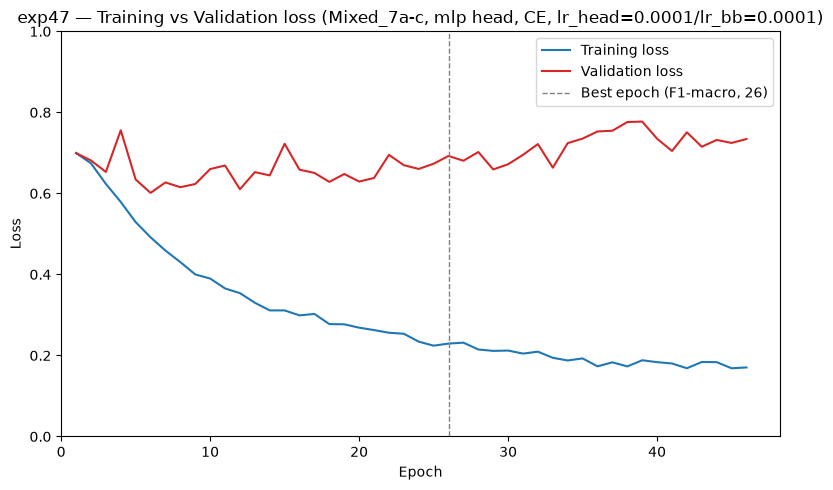

In [18]:
import matplotlib.pyplot as plt

best_epoch = int(np.argmax(val_f1_history)) + 1

for epoch, (t_loss, v_loss, v_f1) in enumerate(zip(train_loss_history, val_loss_history, val_f1_history), start=1):
    marker = "  <-- best (max val F1-macro)" if epoch == best_epoch else ""
    print(
        f"Epoch {epoch:3d} \t Training Loss: {t_loss:.6f} \t Validation Loss: {v_loss:.6f} "
        f"\t Validation F1-macro: {v_f1:.6f}{marker}"
    )

loss_history_path = RUN_DIR / "loss_history.csv"
pd.DataFrame({
    "epoch": range(1, len(train_loss_history) + 1),
    "train_loss": train_loss_history,
    "val_loss": val_loss_history,
    "val_f1_macro": val_f1_history,
}).to_csv(loss_history_path, index=False)
print(f"\nHistorial guardado en: {loss_history_path}")

fig, ax = plt.subplots(figsize=(8, 5))
epochs_range = range(1, len(train_loss_history) + 1)
ax.plot(epochs_range, train_loss_history, label="Training loss", color="#1f77b4")
ax.plot(epochs_range, val_loss_history, label="Validation loss", color="#d62728")
ax.axvline(best_epoch, linestyle="--", color="gray", lw=1, label=f"Best epoch (F1-macro, {best_epoch})")
ax.set_xlim(left=0)
ax.set_ylim(0, 1)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"{EXP_ID} — Training vs Validation loss ({DEPTH_LABEL}, mlp head, CE, lr_head={LR}/lr_bb={LR_BACKBONE})")
ax.legend()
fig.tight_layout()

loss_curve_path = PLOTS_DIR / "loss_curve.png"
fig.savefig(loss_curve_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {loss_curve_path}")
plt.show()

In [19]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)


def evaluate_model(model, checkpoint_path, dataloader, device=device, desc="eval"):
    """Carga `checkpoint_path` en `model` y lo evalúa sobre `dataloader`.

    El caller arma el DataLoader (el `test` de todo el split, o uno nuevo sobre el
    subset de un solo source_dataset — ver celda de abajo) y elige con qué checkpoint
    evaluar; esta función solo hace inferencia + métricas, sin construir datasets ni
    decidir qué filas evaluar, así que sirve igual para el desglose global o por dataset.
    """
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    labels, preds, probs = [], [], []
    with torch.no_grad():
        for data, lbl in tqdm(dataloader, desc=desc, unit="batch", leave=False):
            data = data.to(device, dtype=torch.float)
            logits = model(data)
            p = torch.softmax(logits, dim=1)
            pred = torch.argmax(logits, dim=1)

            labels.extend(lbl.numpy())
            preds.extend(pred.cpu().numpy())
            # p[:, 1] = P(clase 1), score que roc_auc_score espera en binario.
            probs.extend(p[:, 1].cpu().numpy())

    n = len(labels)
    result = {"n_samples": n, "labels": labels, "preds": preds, "probs": probs}
    if n == 0 or len(set(labels)) < 2:
        # AUC/precision/recall/F1 no están bien definidos con una sola clase presente (o 0 muestras).
        result["warning"] = "menos de 2 clases en este subset; AUC/precision/recall/F1 se omiten"
        result["accuracy"] = float(accuracy_score(labels, preds)) if n else None
        result["auc"] = result["precision"] = result["recall"] = result["f1"] = None
    else:
        result["accuracy"] = float(accuracy_score(labels, preds))
        result["auc"] = float(roc_auc_score(labels, probs))
        result["precision"] = float(precision_score(labels, preds, pos_label=1, zero_division=0))
        result["recall"] = float(recall_score(labels, preds, pos_label=1, zero_division=0))
        result["f1"] = float(f1_score(labels, preds, pos_label=1, zero_division=0))
    result["confusion_matrix"] = confusion_matrix(labels, preds, labels=[0, 1]).tolist()
    return result


def save_predictions_csv(manifest_df, result, out_path):
    """Guarda `manifest_df` (las mismas filas que se evaluaron) con 3 columnas nuevas:
    y_true (índice de clase real), y_pred (índice de clase predicho) y y_prob
    (P(clase 1) — el mismo score que roc_auc_score y la curva ROC usan).

    y_true/y_pred/y_prob se asignan por posición, no por índice de fila, así que
    `manifest_df` debe conservar el mismo orden de fila que vio el DataLoader
    (shuffle=False, igual que en toda esta sección) — CSVDataset(dataframe=...) no
    reordena filas, solo resetea el índice, así que esto vale tanto para
    test_processed.data (global) como para un subset filtrado por source_dataset.
    """
    out_df = manifest_df.copy()
    out_df["y_true"] = result["labels"]
    out_df["y_pred"] = result["preds"]
    out_df["y_prob"] = result["probs"]
    out_df.to_csv(out_path, index=False)
    print(f"Predicciones guardadas en: {out_path}")
    return out_path


idx_to_label = {v: k for k, v in train_processed.label_to_idx.items()}
global_result = evaluate_model(model, BEST_MODEL_PATH, test, desc="Test (global)")
all_labels, all_preds, all_probs = global_result["labels"], global_result["preds"], global_result["probs"]
test_acc, test_auc = global_result["accuracy"], global_result["auc"]

save_predictions_csv(test_processed.data, global_result, RUN_DIR / "predictions.csv")

print(f"label_to_idx: {train_processed.label_to_idx}  (clase positiva para AUC = {idx_to_label[1]!r})")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC AUC:  {test_auc:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=[idx_to_label[0], idx_to_label[1]]))

Test (global):   0%|          | 0/53 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/predictions.csv
label_to_idx: {'Benign': 0, 'Malignant': 1}  (clase positiva para AUC = 'Malignant')
Test accuracy: 0.7038
Test ROC AUC:  0.7629

              precision    recall  f1-score   support

      Benign       0.78      0.77      0.78       557
   Malignant       0.55      0.57      0.56       277

    accuracy                           0.70       834
   macro avg       0.67      0.67      0.67       834
weighted avg       0.71      0.70      0.70       834



Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/plots/test_confusion_matrix.png


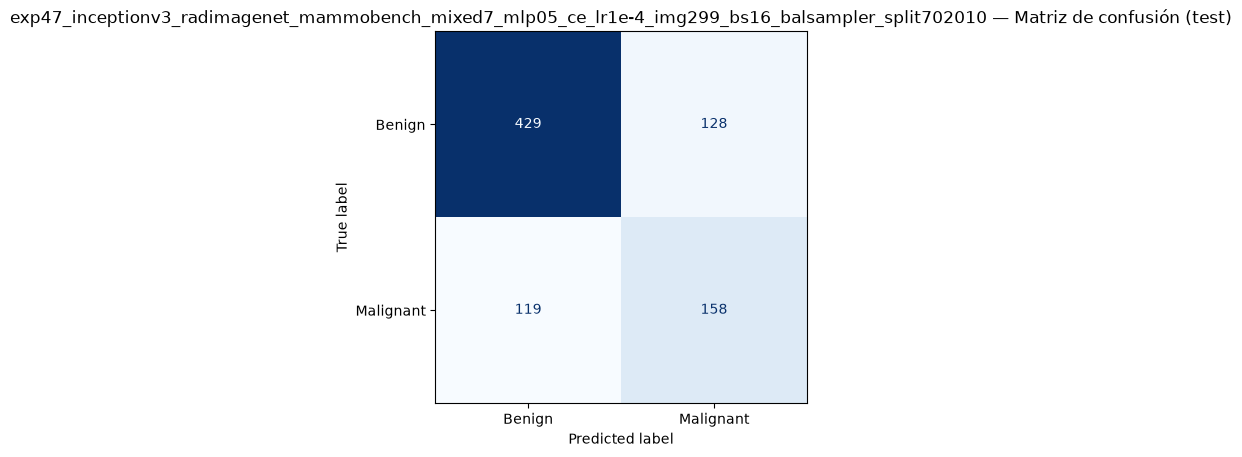

Accuracy  : 0.7038
ROC AUC   : 0.7629
Precision : 0.5524
Recall    : 0.5704
F1-score  : 0.5613


Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/plots/test_roc_curve.png


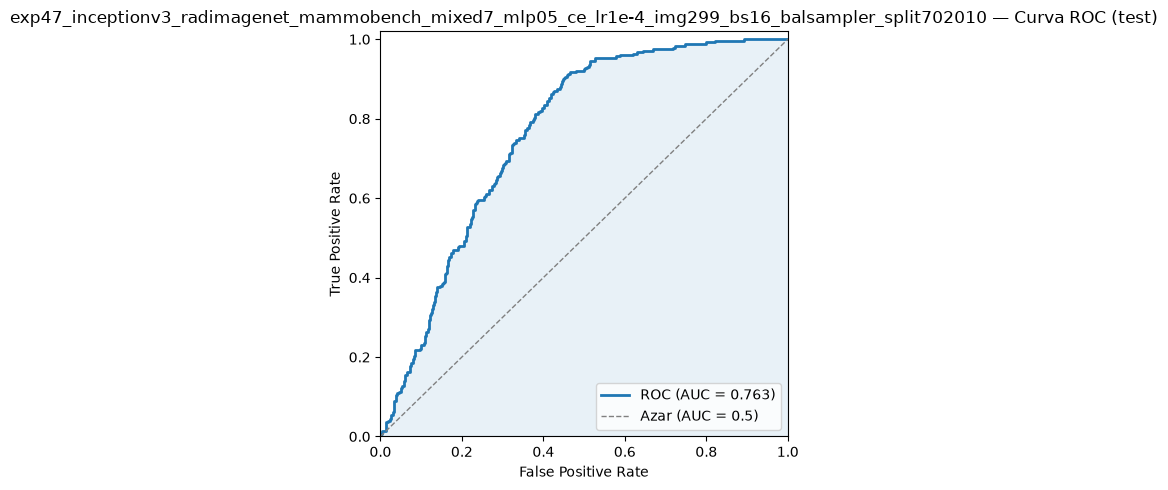

Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/plots/test_metrics_bar.png


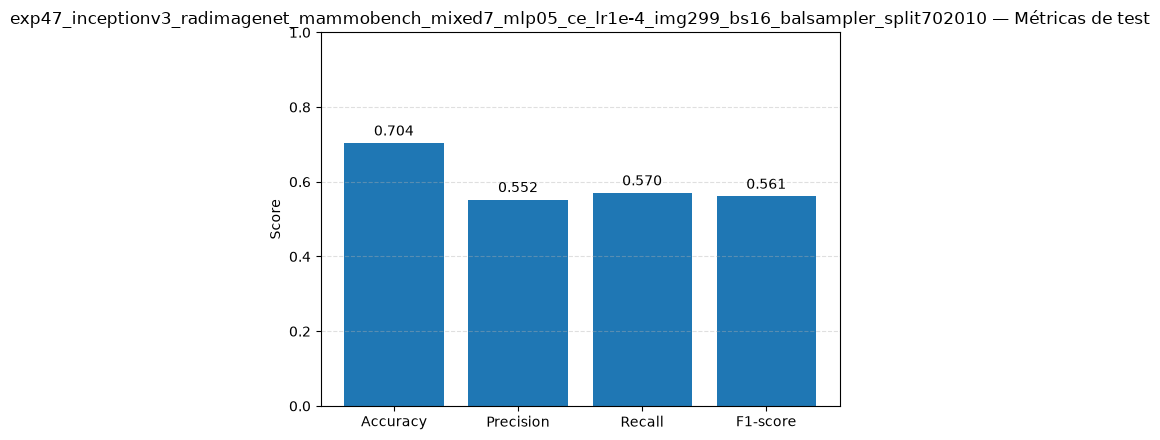

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_curve

test_precision = precision_score(all_labels, all_preds, pos_label=1)
test_recall = recall_score(all_labels, all_preds, pos_label=1)
test_f1 = f1_score(all_labels, all_preds, pos_label=1)
cm = confusion_matrix(all_labels, all_preds)

class_names = [idx_to_label[0], idx_to_label[1]]

fig_cm, ax_cm = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax_cm, cmap="Blues", colorbar=False, values_format="d")
ax_cm.set_title(f"{RUN_NAME} — Matriz de confusión (test)")
fig_cm.tight_layout()

cm_path = PLOTS_DIR / "test_confusion_matrix.png"
fig_cm.savefig(cm_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {cm_path}")
plt.show()

metrics = {
    "Accuracy": test_acc,
    "ROC AUC": test_auc,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-score": test_f1,
}
for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

if wandb_run is not None:
    wandb_run.log({f"test/{k.lower().replace(' ', '_')}": v for k, v in metrics.items()})
    wandb_run.summary["best_epoch"] = best_epoch
    wandb_run.summary["best_val_loss"] = min(val_loss_history)
    wandb_run.summary["best_val_f1_macro"] = max(val_f1_history)

# ROC AUC es el area bajo la curva ROC: se grafica la curva real, no un punto suelto.
fpr, tpr, _ = roc_curve(all_labels, all_probs)

fig_roc, ax_roc = plt.subplots(figsize=(5, 5))
ax_roc.plot(fpr, tpr, color="#1f77b4", lw=2, label=f"ROC (AUC = {test_auc:.3f})")
ax_roc.fill_between(fpr, tpr, alpha=0.1, color="#1f77b4")
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Azar (AUC = 0.5)")
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1.02)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title(f"{RUN_NAME} — Curva ROC (test)")
ax_roc.legend(loc="lower right")
fig_roc.tight_layout()

roc_path = PLOTS_DIR / "test_roc_curve.png"
fig_roc.savefig(roc_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {roc_path}")
plt.show()

# Accuracy/Precision/Recall/F1 son escalares puntuales en el mismo rango [0, 1]: se
# comparan mejor juntos en un solo grafico de barras que en 4 graficos de un punto.
bar_metrics = {k: v for k, v in metrics.items() if k != "ROC AUC"}

fig_bar, ax_bar = plt.subplots(figsize=(6, 4.5))
bars = ax_bar.bar(bar_metrics.keys(), bar_metrics.values(), color="#1f77b4")
ax_bar.set_ylim(0, 1)
ax_bar.set_ylabel("Score")
ax_bar.set_title(f"{RUN_NAME} — Métricas de test")
ax_bar.grid(True, axis="y", linestyle="--", alpha=0.4)
ax_bar.bar_label(bars, fmt="%.3f", padding=3)
fig_bar.tight_layout()

bar_path = PLOTS_DIR / "test_metrics_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {bar_path}")
plt.show()

if wandb_run is not None:
    wandb_run.log({
        "test/confusion_matrix": wandb.Image(str(cm_path)),
        "test/roc_curve": wandb.Image(str(roc_path)),
        "test/metrics_bar": wandb.Image(str(bar_path)),
    })
# wandb_run.finish() se movió al final de la sección per-dataset (más abajo),
# para poder seguir logueando a este mismo run mientras se calcula el desglose.

In [21]:
summary = {
    "experiment": EXP_ID,
    "block": BLOCK,
    "run_name": RUN_NAME,
    "unfrozen": UNFROZEN_DESC,
    "unfreeze_idx": UNFREEZE_IDX,
    "seed": SEED,
    "manifest": MANIFEST_PATH.name,
    "split_scheme": SPLIT_SCHEME,
    "hyperparams": {
        "head": HEAD,
        "architecture": ARCHITECTURE,
        "dropout": DROPOUT if HEAD == "mlp" else None,
        "lr": LR,
        "lr_backbone": LR_BACKBONE,
        "weight_decay": WEIGHT_DECAY,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "patience": PATIENCE,
        "image_size": IMAGE_SIZE,
        "optimizer": "AdamW",
        "loss": "CrossEntropyLoss",
        "class_weight": None,  # balanceo por sampler, no por loss
        "sampler": "WeightedRandomSampler(source_dataset x clase, replacement=True)",
        "sampler_alpha": SAMPLER_ALPHA,
        "scheduler": "CosineAnnealingLR",
        "augmentation": f"RandomRotation({ROTATION_DEGREES}) + RandomHorizontalFlip(p=0.5)",
        "seed": SEED,
        "best_checkpoint_metric": "val_f1_macro",
    },
    "epochs_run": len(train_loss_history),
    "best_epoch": best_epoch,
    "best_val_loss": float(min(val_loss_history)),
    "best_val_f1_macro": float(max(val_f1_history)),
    "final_train_loss": float(train_loss_history[-1]),
    "final_val_loss": float(val_loss_history[-1]),
    "test": {
        "accuracy": float(test_acc),
        "auc": float(test_auc),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1": float(test_f1),
        "confusion_matrix": cm.tolist(),
        "class_names": class_names,
    },
    # Desglose por source_dataset (cmmd/kau-bcmd/cdd-cesm/inbreast): archivo aparte,
    # calculado en las celdas de abajo, no inline aquí — ver PER_DATASET_DIR.
    "per_dataset_metrics_path": str(PER_DATASET_DIR / "metrics_per_dataset.json"),
    "checkpoints": {
        "best": str(BEST_MODEL_PATH),
        "last": str(LAST_MODEL_PATH),
    },
}

metrics_path = RUN_DIR / "metrics.json"
metrics_path.write_text(json.dumps(summary, indent=2))
print(f"Resumen guardado en: {metrics_path}")
print(json.dumps(summary["test"], indent=2))

Resumen guardado en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/metrics.json
{
  "accuracy": 0.7038369304556354,
  "auc": 0.7628994938070763,
  "precision": 0.5524475524475524,
  "recall": 0.5703971119133574,
  "f1": 0.5612788632326821,
  "confusion_matrix": [
    [
      429,
      128
    ],
    [
      119,
      158
    ]
  ],
  "class_names": [
    "Benign",
    "Malignant"
  ]
}


In [22]:
per_dataset_metrics = {}
for name in sorted(test_processed.data["source_dataset"].unique()):
    subset_df = test_processed.data[test_processed.data["source_dataset"] == name]
    subset_dataset = CSVDataset(
        dataframe=subset_df, root_dir=DATASET_ROOT, transform=val_transform,
        label_to_idx=train_processed.label_to_idx,
    )
    subset_loader = DataLoader(subset_dataset, batch_size=BATCH_SIZE, shuffle=False)

    result = evaluate_model(model, BEST_MODEL_PATH, subset_loader, desc=f"Test ({name})")
    save_predictions_csv(subset_df, result, PER_DATASET_DIR / f"predictions_{name}.csv")
    for key in ("labels", "preds", "probs"):
        result.pop(key, None)  # ya están volcadas al csv de predicciones; no hacen falta en el json de métricas
    per_dataset_metrics[name] = result

for name, m in per_dataset_metrics.items():
    print(f"--- {name} (n={m['n_samples']}) ---")
    for k, v in m.items():
        if k not in ("confusion_matrix", "n_samples"):
            print(f"  {k:10s}: {v}")
    print()

if wandb_run is not None:
    for name, m in per_dataset_metrics.items():
        wandb_run.log({
            f"test_per_dataset/{name}/{k}": v
            for k, v in m.items()
            if isinstance(v, (int, float))
        })

per_dataset_metrics_path = PER_DATASET_DIR / "metrics_per_dataset.json"
per_dataset_metrics_path.write_text(json.dumps(per_dataset_metrics, indent=2))
print(f"Métricas por dataset guardadas en: {per_dataset_metrics_path}")

Test (cdd-cesm):   0%|          | 0/7 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/per_dataset/predictions_cdd-cesm.csv


Test (cmmd):   0%|          | 0/30 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/per_dataset/predictions_cmmd.csv


Test (inbreast):   0%|          | 0/3 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/per_dataset/predictions_inbreast.csv


Test (kau-bcmd):   0%|          | 0/14 [00:00<?, ?batch/s]

Predicciones guardadas en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/per_dataset/predictions_kau-bcmd.csv
--- cdd-cesm (n=100) ---
  accuracy  : 0.66
  auc       : 0.7521483491632746
  precision : 0.48
  recall    : 0.36363636363636365
  f1        : 0.41379310344827586

--- cmmd (n=472) ---
  accuracy  : 0.6101694915254238
  auc       : 0.6352497305066476
  precision : 0.5958333333333333
  recall    : 0.6217391304347826
  f1        : 0.6085106382978723

--- inbreast (n=40) ---
  accuracy  : 0.775
  auc       : 0.71875
  precision : 0.3333333333333333
  recall    : 0.125
  f1        : 0.18181818181818182

--- kau-bcmd (n=222) ---
  accuracy  : 0.9099099099099099
  auc       : 0.7569444444444444
  precision : 0.1111111111111111
  recall    : 0.3333333333333333
  f1        : 0.16666666666666666

Métri

Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/per_dataset/test_metrics_per_dataset.png


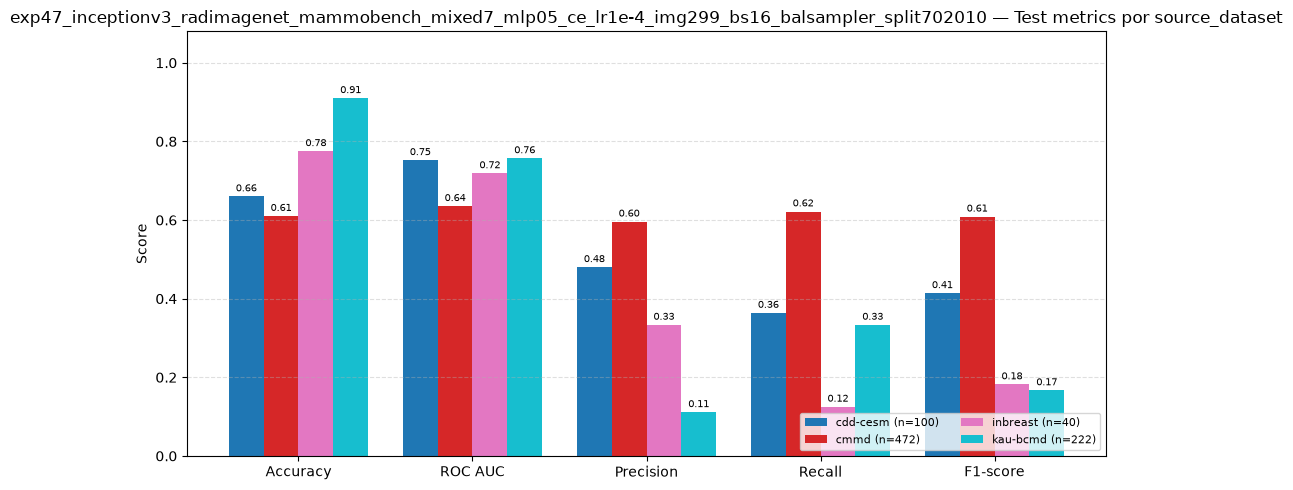

Figura guardada en: /media/imagenesmedicas/DATA1/01-ImagenesMedicas-US1/13-PregradoJulian/Federal Learning/infraestructura federada/Federal-Learning/runs/exp47_inceptionv3_radimagenet_mammobench_mixed7_mlp05_ce_lr1e-4_img299_bs16_balsampler_split702010/per_dataset/test_confusion_matrix_per_dataset.png


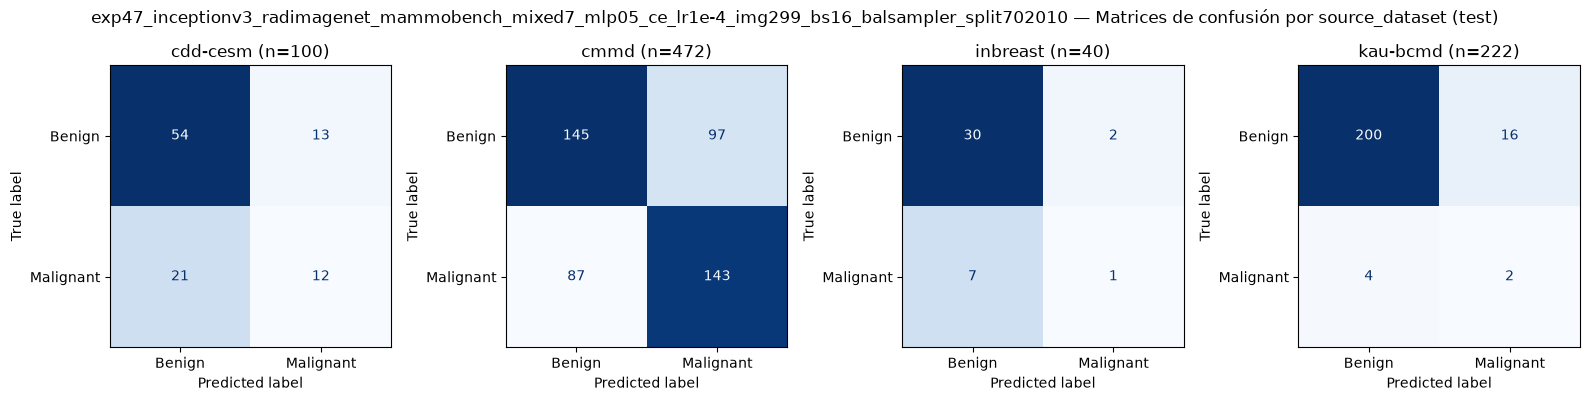

In [23]:
dataset_names = list(per_dataset_metrics.keys())
metric_keys = ["accuracy", "auc", "precision", "recall", "f1"]
metric_labels = ["Accuracy", "ROC AUC", "Precision", "Recall", "F1-score"]

# Barras agrupadas: un grupo por métrica, una barra por dataset — las 5 métricas
# viven en [0, 1], así que se leen mejor juntas que en 5 gráficos sueltos.
fig_bar, ax_bar = plt.subplots(figsize=(10, 5))
x = np.arange(len(metric_keys))
width = 0.8 / len(dataset_names)
colors = plt.cm.tab10(np.linspace(0, 1, len(dataset_names)))

for i, name in enumerate(dataset_names):
    values = [per_dataset_metrics[name][k] or 0.0 for k in metric_keys]
    offset = (i - (len(dataset_names) - 1) / 2) * width
    bars = ax_bar.bar(
        x + offset, values, width,
        label=f"{name} (n={per_dataset_metrics[name]['n_samples']})", color=colors[i],
    )
    ax_bar.bar_label(bars, fmt="%.2f", padding=2, fontsize=7)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_labels)
ax_bar.set_ylim(0, 1.08)
ax_bar.set_ylabel("Score")
ax_bar.set_title(f"{RUN_NAME} — Test metrics por source_dataset")
ax_bar.legend(loc="lower right", fontsize=8, ncol=2)
ax_bar.grid(axis="y", linestyle="--", alpha=0.4)
fig_bar.tight_layout()

per_dataset_bar_path = PER_DATASET_DIR / "test_metrics_per_dataset.png"
fig_bar.savefig(per_dataset_bar_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {per_dataset_bar_path}")
plt.show()

# Una matriz de confusión por dataset, en una sola grilla para comparar de un vistazo.
n_ds = len(dataset_names)
fig_cm2, axes_cm2 = plt.subplots(1, n_ds, figsize=(4 * n_ds, 4))
if n_ds == 1:
    axes_cm2 = [axes_cm2]
for ax_cm2, name in zip(axes_cm2, dataset_names):
    cm_ds = np.array(per_dataset_metrics[name]["confusion_matrix"])
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_ds, display_labels=class_names)
    disp2.plot(ax=ax_cm2, cmap="Blues", colorbar=False, values_format="d")
    ax_cm2.set_title(f"{name} (n={per_dataset_metrics[name]['n_samples']})")
fig_cm2.suptitle(f"{RUN_NAME} — Matrices de confusión por source_dataset (test)")
fig_cm2.tight_layout()

per_dataset_cm_path = PER_DATASET_DIR / "test_confusion_matrix_per_dataset.png"
fig_cm2.savefig(per_dataset_cm_path, dpi=150, bbox_inches="tight")
print(f"Figura guardada en: {per_dataset_cm_path}")
plt.show()

if wandb_run is not None:
    wandb_run.log({
        "test_per_dataset/metrics_bar": wandb.Image(str(per_dataset_bar_path)),
        "test_per_dataset/confusion_matrices": wandb.Image(str(per_dataset_cm_path)),
    })
    wandb_run.finish()